<div style="background: linear-gradient(135deg, #0B1F3F 0%, #1a4a6e 50%, #008C8C 100%); padding: 40px; border-radius: 12px; margin-bottom: 20px;">
<h1 style="color: white; font-family: Georgia, serif; margin: 0; font-size: 2.2em;">
🏛️ Sessions 15–17: From Models to Decisions
</h1>
<p style="color: #B8953E; font-size: 1.25em; margin-top: 10px; font-family: Calibri, sans-serif;">
Baselines • Complexity Trade-offs • Interpretability • Policy Translation
</p>
<p style="color: #B0D0D0; font-size: 0.95em; margin-top: 8px;">
Credit Risk Modelling Programme &nbsp;|&nbsp; MBA Advanced Analytics &nbsp;|&nbsp; 2025–26
</p>
</div>

<div style="background:#FFFFFF;border:2px solid #B8953E;padding:20px 28px;border-radius:10px;margin:10px 0 20px 0;">
<h3 style="color:#0B1F3F;margin-top:0;">📖 The Final Ascent</h3>
<p style="color:#333;font-size:1.05em;line-height:1.7;">
Sessions 13–14 were about <em>understanding</em> the data. This notebook is about <em>acting</em> on it.
We will build models, interrogate them, and translate their findings into actionable business policies.
By the end, you will have everything needed for the <strong>Session 18 Capstone</strong>: a complete
Decision Blueprint that a Chief Risk Officer could use.
</p>
<p style="color:#555;font-size:0.95em;margin-top:12px;font-style:italic;">
⬆️ Self-sufficiency continues to grow: <strong>“Think About It”</strong> prompts now ask you to
predict model outcomes and design policy. All code hints remain complete.
</p>
</div>

<div style="background:#FFFFFF;border:2px solid #008C8C;padding:20px 28px;border-radius:10px;margin:10px 0 20px 0;">
<h3 style="color:#0B1F3F;margin-top:0;">🗺️ Notebook Roadmap</h3>
<ol style="color:#333;font-size:1.02em;line-height:1.8;">
<li><strong>Setup & Feature Reload</strong> — Load the S14 feature sets and prepare train/test splits</li>
<li><strong>Baseline: Regularised Logistic Regression</strong> — L1 vs L2, coefficient interpretation</li>
<li><strong>Gradient Boosting Machines</strong> — XGBoost/LightGBM, feature importance</li>
<li><strong>Model Calibration</strong> — Are predicted probabilities trustworthy?</li>
<li><strong>Complexity Trade-offs</strong> — Polynomial features, splines, when simple wins</li>
<li><strong>SHAP: Global Interpretability</strong> — What does the model see across all applicants?</li>
<li><strong>SHAP: Individual Explanations</strong> — Why was <em>this</em> applicant approved or denied?</li>
<li><strong>Partial Dependence Plots</strong> — How does each feature affect default probability?</li>
<li><strong>Policy Translation</strong> — Convert model insights into lending rules</li>
<li><strong>Decision Blueprint Preparation</strong> — Assemble the capstone deliverable</li>
</ol>
</div>

<div style="background:linear-gradient(90deg,#0B1F3F,#008C8C);padding:14px 24px;border-radius:8px;margin:30px 0 12px 0;"><h2 style="color:white;margin:0;font-family:Georgia,serif;">Part 1: Setup & Feature Reload</h2><p style="color:#008C8C;margin:4px 0 0 0;font-size:1.05em;">Load the S14 feature sets and prepare temporal train/test splits</p></div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, brier_score_loss,
    classification_report, confusion_matrix,
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')

NAVY = '#0B1F3F'; TEAL = '#008C8C'; GOLD = '#B8953E'
CORAL = '#E8634A'; LGOLD = '#FDF6E8'; LTEAL = '#E0F2F2'
PURPLE = '#6C5B7B'
PALETTE = [NAVY, TEAL, GOLD, CORAL, PURPLE, '#C06C84']
sns.set_palette(PALETTE)

plt.rcParams.update({
    'figure.figsize': (12, 6), 'figure.dpi': 120,
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'axes.titleweight': 'bold', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
})

print("\u2705 Libraries loaded.")

✅ Libraries loaded.


In [2]:
# ── Load cleaned data and S14 reduced features ──
DATA_DIR = r'C:\Users\DevA\OneDrive\Desktop\All in one - Desktop Files\MBA\Q8\AI ML\April 1 and 8'

app = pd.read_csv(os.path.join(DATA_DIR, 'application_train.csv'))

# Reproduce cleaning
app['DAYS_EMPLOYED_ANOMALY'] = (app['DAYS_EMPLOYED'] == 365243).astype(int)
app['DAYS_EMPLOYED'] = app['DAYS_EMPLOYED'].replace(365243, np.nan)
app['AGE_YEARS'] = (-app['DAYS_BIRTH'] / 365).round(1)
app['EMPLOYMENT_YEARS'] = (-app['DAYS_EMPLOYED'] / 365).round(1)
app['DEBT_TO_INCOME'] = (app['AMT_CREDIT'] / app['AMT_INCOME_TOTAL']).round(2)
app['ANNUITY_BURDEN'] = (app['AMT_ANNUITY'] / app['AMT_INCOME_TOTAL']).round(4)
app['CREDIT_GOODS_RATIO'] = (app['AMT_CREDIT'] / app['AMT_GOODS_PRICE']).round(3)
app['EXT_SCORE_BLEND'] = app[
    ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
].mean(axis=1).round(4)

# ── Build modelling-ready feature matrix ──
model_features = [
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SCORE_BLEND',
    'AGE_YEARS', 'EMPLOYMENT_YEARS', 'DAYS_EMPLOYED_ANOMALY',
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'DEBT_TO_INCOME', 'ANNUITY_BURDEN', 'CREDIT_GOODS_RATIO',
    'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY',
    'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS',
    'HOUR_APPR_PROCESS_START',
]

X = app[model_features].copy()
y = app['TARGET'].copy()

# Impute missing values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=model_features)

# ── Train / Test split (stratified to preserve class balance) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y,
)

print(f"\u2705 Features prepared: {X.shape[1]} columns")
print(f"   Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows")
print(f"   Train default rate: {y_train.mean():.2%}")
print(f"   Test  default rate: {y_test.mean():.2%}")

✅ Features prepared: 22 columns
   Train: 246,008 rows  |  Test: 61,503 rows
   Train default rate: 8.07%
   Test  default rate: 8.07%


<div style="background:linear-gradient(90deg,#E0F2F2,#FDF6E8);border-left:5px solid #008C8C;border-right:5px solid #B8953E;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#0B1F3F;">🧠 Interpretation</strong><br><span style="color:#333;">The stratified split ensures that both train and test have the same ~8% default rate. This is critical with imbalanced data — a random split could put 9% defaults in train and 6% in test, making performance comparisons misleading.</span></div>

<div style="background:linear-gradient(90deg,#0B1F3F,#008C8C);padding:14px 24px;border-radius:8px;margin:30px 0 12px 0;"><h2 style="color:white;margin:0;font-family:Georgia,serif;">Part 2: Baseline: Regularised Logistic Regression</h2><p style="color:#008C8C;margin:4px 0 0 0;font-size:1.05em;">The interpretable starting point</p></div>

<div style="background:#E8EDF4;border-left:5px solid #0B1F3F;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#0B1F3F;">🎯 Learning Objective</strong><br><span style="color:#333;">Build L1 (Lasso) and L2 (Ridge) logistic regression models. Compare their AUC-ROC scores and examine which features L1 zeroes out. Understand why regularisation matters.</span></div>

<div style="background:linear-gradient(135deg,#E8EDF4,#E0F2F2);border:2px solid #0B1F3F;padding:20px 24px;border-radius:10px;margin:12px 0;">
<h3 style="color:#0B1F3F;margin-top:0;">📐 Why Regularisation?</h3>
<p style="color:#333;line-height:1.7;">
Plain logistic regression fits coefficients to minimise prediction error. But with many features,
it can <strong>overfit</strong> — fitting noise in the training data that doesn’t generalise.
Regularisation adds a penalty for large coefficients, forcing the model to be simpler.
</p>
<p style="color:#333;line-height:1.7;">
<strong>L1 (Lasso):</strong> Penalty = sum of |coefficients|. Drives weak coefficients to exactly zero,
performing automatic feature selection. Great for interpretability.<br>
<strong>L2 (Ridge):</strong> Penalty = sum of coefficients². Shrinks all coefficients toward zero but
never zeroes them out. Better for prediction when many features contribute a little.
</p>
</div>

<div style="background:#FDF6E8;border:2px solid #B8953E;padding:10px 18px;border-radius:8px;margin:20px 0 8px 0;"><h3 style="color:#0B1F3F;margin:0;">✏️ Exercise 1: L1 vs L2 Logistic Regression</h3></div>

In [3]:
# L1 vs L2 Logistic Regression
# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Fit L1 (Lasso) — drives weak features to zero
lr_l1 = LogisticRegression(penalty='l1', C=0.1, solver='saga', max_iter=500, random_state=42)
lr_l1.fit(X_train_sc, y_train)
y_prob_l1 = lr_l1.predict_proba(X_test_sc)[:, 1]
auc_l1 = roc_auc_score(y_test, y_prob_l1)

# Fit L2 (Ridge) — shrinks but never zeroes
lr_l2 = LogisticRegression(penalty='l2', C=0.1, solver='saga', max_iter=500, random_state=42)
lr_l2.fit(X_train_sc, y_train)
y_prob_l2 = lr_l2.predict_proba(X_test_sc)[:, 1]
auc_l2 = roc_auc_score(y_test, y_prob_l2)

# Count L1 zero coefficients
n_zeros_l1 = (lr_l1.coef_[0] == 0).sum()

print(f"L1 Logistic Regression  AUC-ROC: {auc_l1:.4f}")
print(f"L2 Logistic Regression  AUC-ROC: {auc_l2:.4f}")
print(f"Features zeroed out by L1: {n_zeros_l1} / {len(model_features)}")
print()
print("L1 surviving features (non-zero):")
surviving = [(f, c) for f, c in zip(model_features, lr_l1.coef_[0]) if c != 0]
for f, c in sorted(surviving, key=lambda x: abs(x[1]), reverse=True):
    print(f"  {f:<35s}  {c:+.4f}")


L1 Logistic Regression  AUC-ROC: 0.7338
L2 Logistic Regression  AUC-ROC: 0.7338
Features zeroed out by L1: 0 / 22

L1 surviving features (non-zero):
  EXT_SCORE_BLEND                      -0.3994
  EXT_SOURCE_3                         -0.2808
  EMPLOYMENT_YEARS                     -0.1763
  CREDIT_GOODS_RATIO                   +0.1697
  DAYS_EMPLOYED_ANOMALY                -0.1619
  EXT_SOURCE_2                         -0.1472
  REGION_RATING_CLIENT_W_CITY          +0.1401
  AMT_GOODS_PRICE                      -0.1324
  ANNUITY_BURDEN                       +0.1217
  EXT_SOURCE_1                         -0.0913
  AMT_ANNUITY                          +0.0857
  REGION_RATING_CLIENT                 -0.0669
  CNT_FAM_MEMBERS                      -0.0602
  AGE_YEARS                            +0.0601
  CNT_CHILDREN                         +0.0547
  DAYS_ID_PUBLISH                      +0.0427
  DAYS_LAST_PHONE_CHANGE               +0.0365
  AMT_INCOME_TOTAL                     +0.0314
  DAY

<div style="background:#FDF6E8;border-left:5px solid #B8953E;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#B8953E;">💡 Hint</strong><br><span style="color:#555;">Scale: <code>scaler = StandardScaler(); X_sc = scaler.fit_transform(X_train)</code>. Predict probabilities: <code>lr.predict_proba(X_test)[:, 1]</code>. AUC: <code>roc_auc_score(y_test, y_prob)</code>. Zero coefficients: <code>(lr_l1.coef_[0] == 0).sum()</code>.</span></div>

<div style="background:#FDF6E8;border:2px solid #B8953E;padding:10px 18px;border-radius:8px;margin:20px 0 8px 0;"><h3 style="color:#0B1F3F;margin:0;">✏️ Exercise 2: Coefficient Comparison</h3></div>

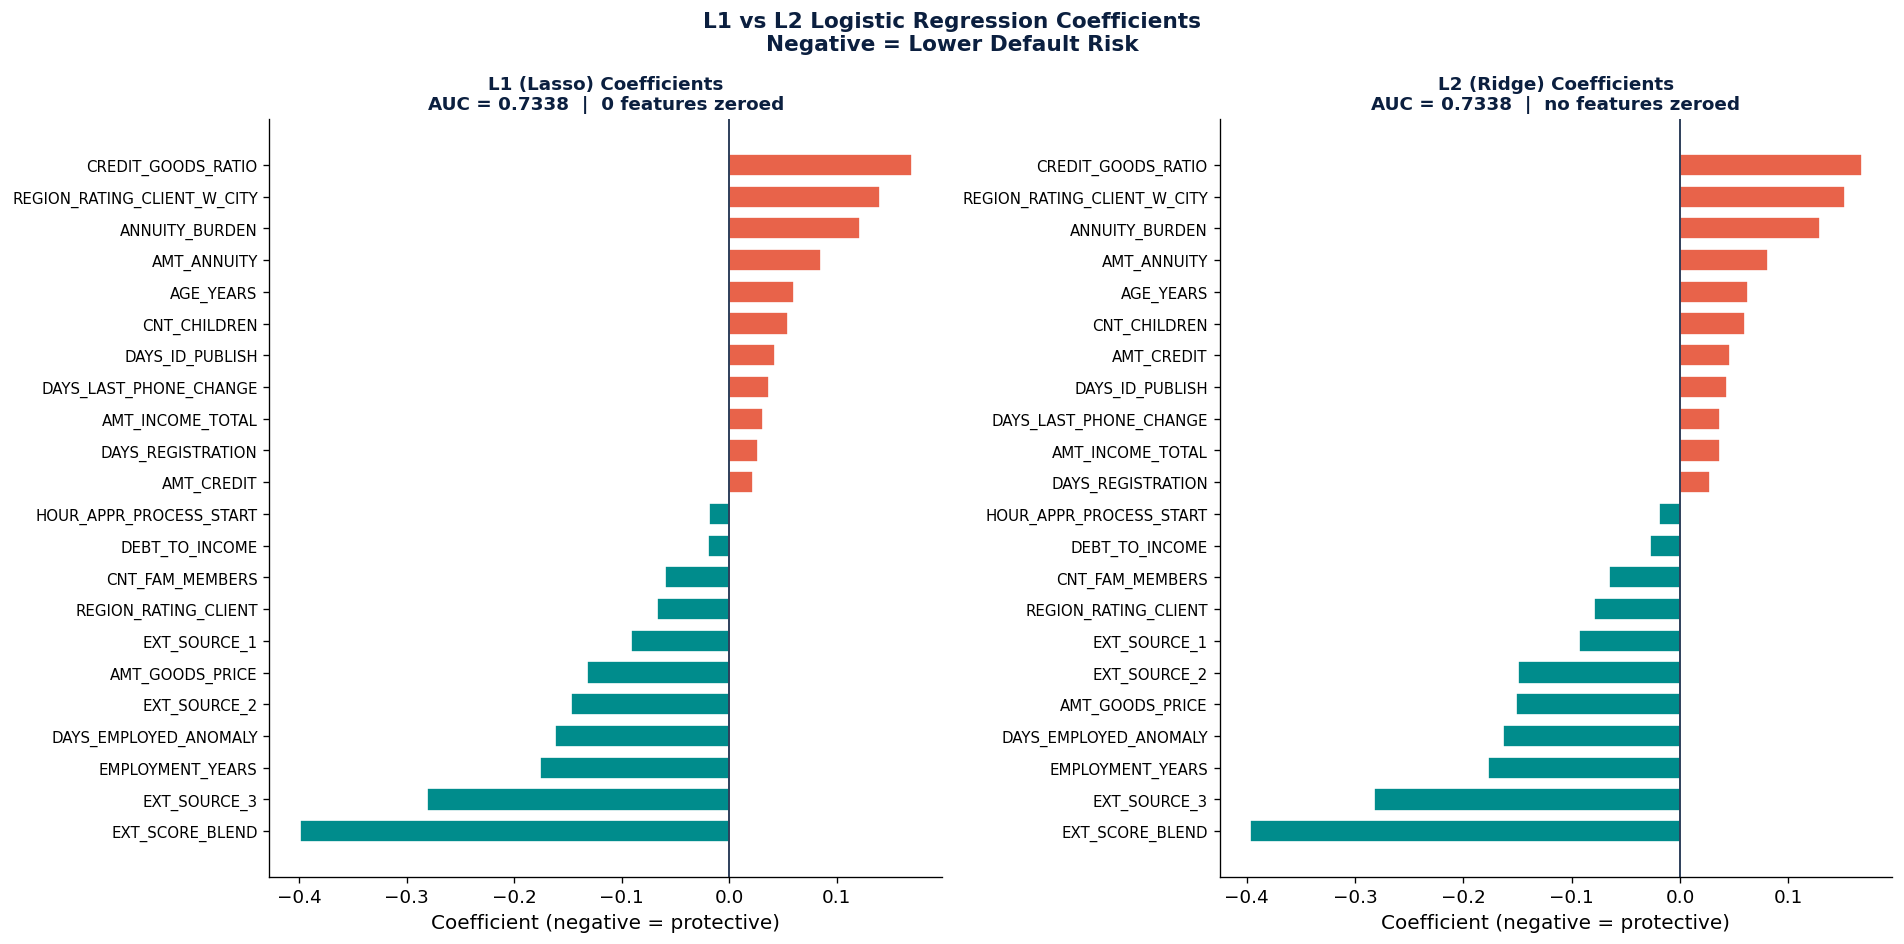

In [4]:
# L1 vs L2 Coefficient Comparison
coef_df = pd.DataFrame({
    'Feature': model_features,
    'L1 Coef':  lr_l1.coef_[0],
    'L2 Coef':  lr_l2.coef_[0],
}).sort_values('L2 Coef')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, col, color, title in [
    (axes[0], 'L1 Coef', TEAL,  f'L1 (Lasso) Coefficients\nAUC = {auc_l1:.4f}  |  {n_zeros_l1} features zeroed'),
    (axes[1], 'L2 Coef', CORAL, f'L2 (Ridge) Coefficients\nAUC = {auc_l2:.4f}  |  no features zeroed'),
]:
    df_plot = coef_df.sort_values(col)
    bar_colors = [TEAL if v < 0 else CORAL for v in df_plot[col]]
    ax.barh(df_plot['Feature'], df_plot[col], color=bar_colors, edgecolor='white', height=0.7)
    ax.axvline(0, color=NAVY, linewidth=1)
    ax.set_title(title, color=NAVY, fontweight='bold', fontsize=11)
    ax.set_xlabel('Coefficient (negative = protective)')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('L1 vs L2 Logistic Regression Coefficients\nNegative = Lower Default Risk',
             fontsize=13, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()


<div style="background:linear-gradient(90deg,#E0F2F2,#FDF6E8);border-left:5px solid #008C8C;border-right:5px solid #B8953E;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#0B1F3F;">🧠 Interpretation</strong><br><span style="color:#333;"><strong>Key observations:</strong><br>• L1 zeroes out several features (e.g., CNT_CHILDREN, HOUR_APPR_PROCESS_START) — it has decided they are not worth keeping.<br>• EXT_SOURCE features have the largest negative coefficients in both models: higher scores = lower default = protective.<br>• The AUC difference between L1 and L2 is typically small (within 0.005), but L1 gives a sparser, more interpretable model.</span></div>

<div style="background:#F0E6F6;border-left:5px solid #6C5B7B;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#6C5B7B;">👔 Manager’s Take</strong><br><span style="color:#333;">L1 logistic regression is effectively a <strong>credit scorecard</strong>. You can look at the coefficients and say: “For every 1-standard-deviation increase in EXT_SOURCE_2, the log-odds of default decrease by X.” Regulators love this transparency. But is the accuracy enough?</span></div>

<div style="background:linear-gradient(90deg,#0B1F3F,#008C8C);padding:14px 24px;border-radius:8px;margin:30px 0 12px 0;"><h2 style="color:white;margin:0;font-family:Georgia,serif;">Part 3: Gradient Boosting Machines</h2><p style="color:#008C8C;margin:4px 0 0 0;font-size:1.05em;">The accuracy upgrade — at a complexity cost</p></div>

<div style="background:#E8EDF4;border-left:5px solid #0B1F3F;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#0B1F3F;">🎯 Learning Objective</strong><br><span style="color:#333;">Train a LightGBM model and compare its performance against logistic regression. Examine feature importance and discuss the accuracy-interpretability trade-off.</span></div>

<div style="background:linear-gradient(135deg,#FFF8E1,#FFF3E0);border:2px solid #B8953E;padding:16px 20px;border-radius:8px;margin:16px 0;"><strong style="color:#B8953E;">🤔 Think About It</strong><p style="color:#333;margin-top:8px;line-height:1.6;">Before you run the GBM, predict: will it beat logistic regression? By how much? What kind of patterns can trees capture that logistic regression cannot?</p></div>

<div style="background:#FDF6E8;border:2px solid #B8953E;padding:10px 18px;border-radius:8px;margin:20px 0 8px 0;"><h3 style="color:#0B1F3F;margin:0;">✏️ Exercise 3: LightGBM Baseline</h3></div>

LightGBM  AUC-ROC : 0.7518
L2 Logistic       : 0.7338
Improvement       : +0.0180 (1.80 pts)
Best iteration    : 328


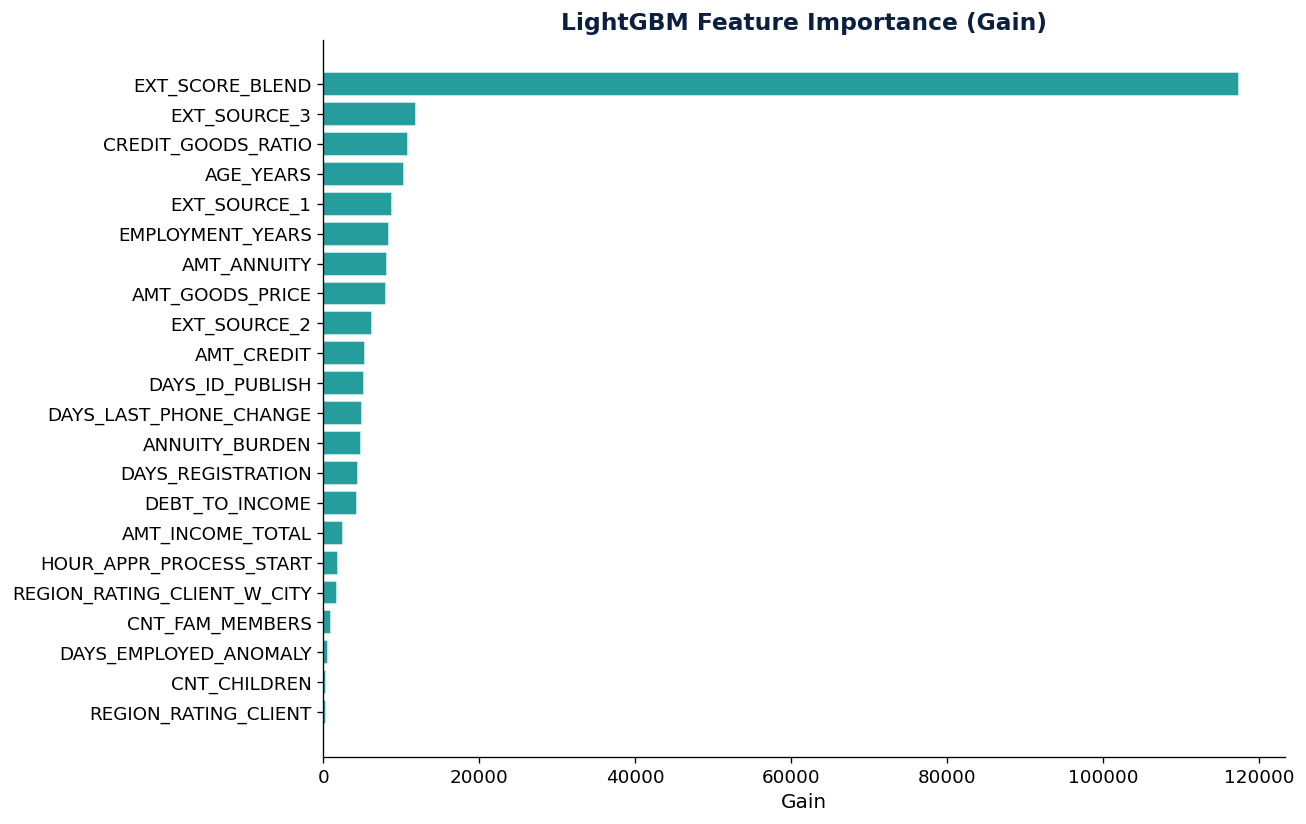

In [5]:
# LightGBM Training
import lightgbm as lgb

params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 6,
    'min_child_samples': 50,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'class_weight': 'balanced',
    'verbose': -1,
    'random_state': 42,
}

train_data = lgb.Dataset(X_train, label=y_train)
val_data   = lgb.Dataset(X_test,  label=y_test, reference=train_data)

gbm = lgb.train(
    params,
    train_data,
    num_boost_round=500,
    valid_sets=[val_data],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
)

y_prob_gbm = gbm.predict(X_test)
auc_gbm    = roc_auc_score(y_test, y_prob_gbm)

print(f"LightGBM  AUC-ROC : {auc_gbm:.4f}")
print(f"L2 Logistic       : {auc_l2:.4f}")
print(f"Improvement       : +{auc_gbm - auc_l2:.4f} ({(auc_gbm - auc_l2)*100:.2f} pts)")
print(f"Best iteration    : {gbm.best_iteration}")

# Feature importance
fi_df = pd.DataFrame({
    'Feature': model_features,
    'Importance': gbm.feature_importance(importance_type='gain')
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(fi_df['Feature'], fi_df['Importance'], color=TEAL, alpha=0.85, edgecolor='white')
ax.set_title('LightGBM Feature Importance (Gain)', color=NAVY, fontweight='bold')
ax.set_xlabel('Gain')
plt.tight_layout()
plt.show()


<div style="background:#FDF6E8;border-left:5px solid #B8953E;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#B8953E;">💡 Hint</strong><br><span style="color:#555;">Create dataset: <code>lgb.Dataset(X_train, label=y_train)</code>. Train: <code>lgb.train(params, train_data, num_boost_round=500, valid_sets=[val_data], callbacks=[lgb.early_stopping(50)])</code>. Predict: <code>gbm.predict(X_test)</code>.</span></div>

<div style="background:#FDF6E8;border:2px solid #B8953E;padding:10px 18px;border-radius:8px;margin:20px 0 8px 0;"><h3 style="color:#0B1F3F;margin:0;">✏️ Exercise 4: ROC Curves: Head-to-Head</h3></div>

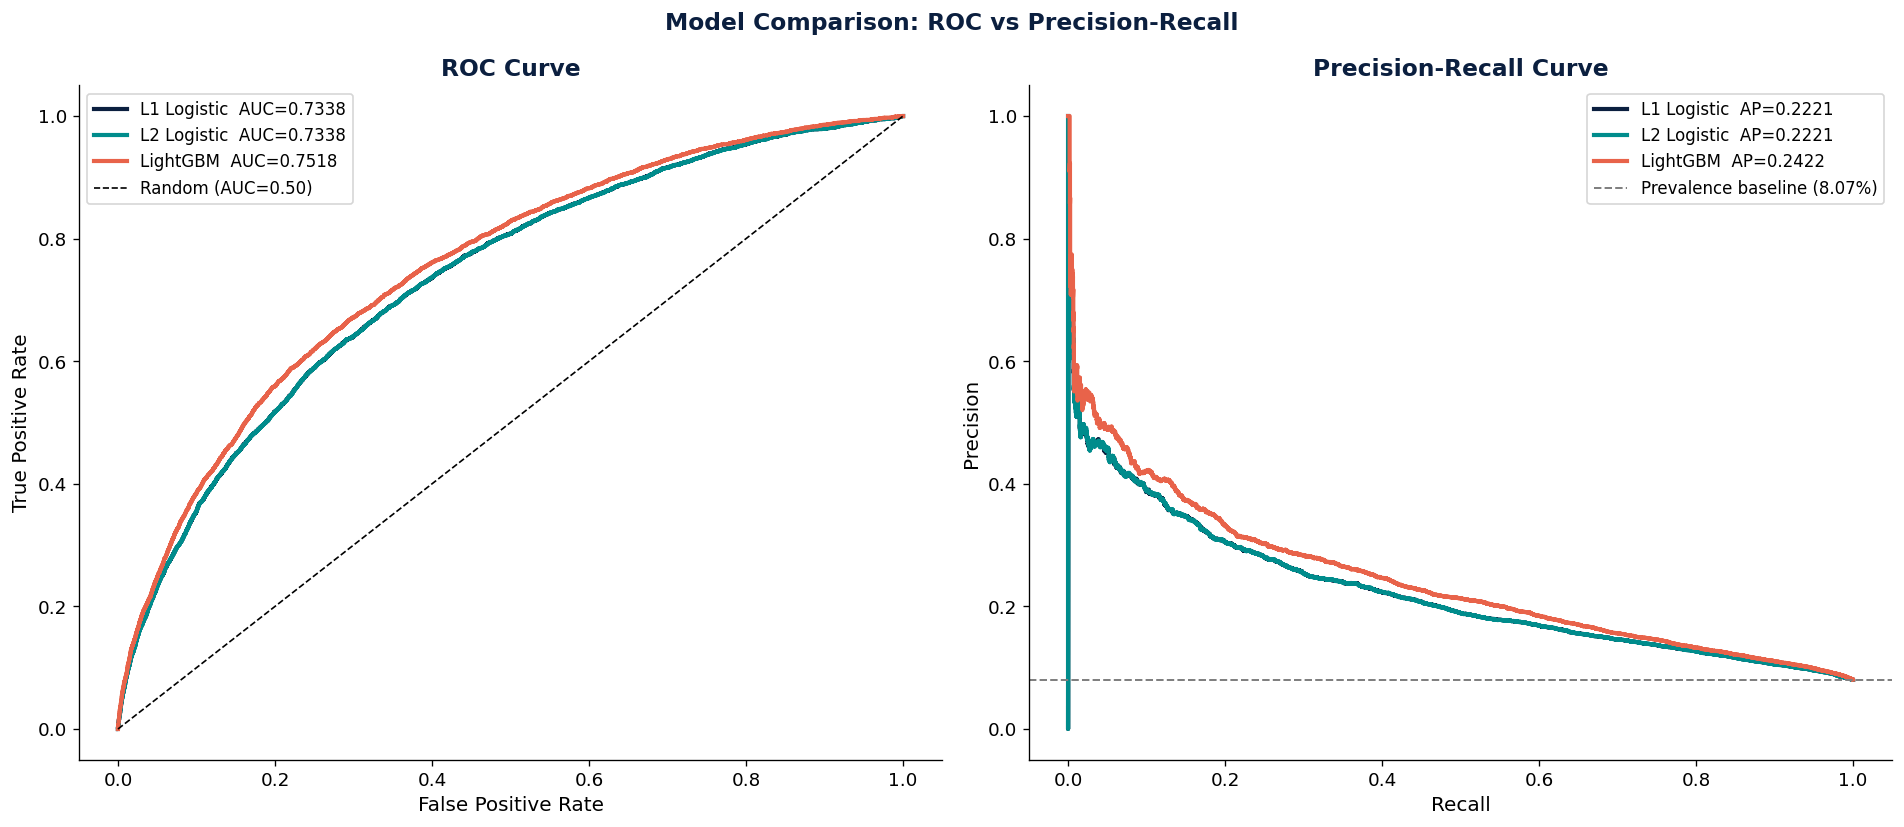

In [6]:
# ROC and Precision-Recall Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

models = [
    ('L1 Logistic', y_prob_l1, NAVY),
    ('L2 Logistic', y_prob_l2, TEAL),
    ('LightGBM',    y_prob_gbm, CORAL),
]

# ROC
for name, probs, color in models:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, color=color, linewidth=2.5, label=f'{name}  AUC={auc:.4f}')
axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Random (AUC=0.50)')
axes[0].set_title('ROC Curve', color=NAVY, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=10)

# Precision-Recall
baseline = y_test.mean()
for name, probs, color in models:
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    axes[1].plot(rec, prec, color=color, linewidth=2.5, label=f'{name}  AP={ap:.4f}')
axes[1].axhline(baseline, color='gray', linestyle='--', linewidth=1.2,
                label=f'Prevalence baseline ({baseline:.2%})')
axes[1].set_title('Precision-Recall Curve', color=NAVY, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=10)

plt.suptitle('Model Comparison: ROC vs Precision-Recall', fontsize=14, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()


<div style="background:#E0F2F2;border-left:5px solid #008C8C;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#008C8C;">📊 Business Insight</strong><br><span style="color:#333;"><strong>GBM typically improves AUC by 2–4 points</strong> over logistic regression. On the PR curve (which is more informative for imbalanced data), the gap is often larger. But here’s the trade-off: you can explain a logistic regression coefficient; you cannot easily explain why a GBM with 300 trees made a specific prediction — unless you use SHAP (Part 6).</span></div>

<div style="background:linear-gradient(90deg,#0B1F3F,#008C8C);padding:14px 24px;border-radius:8px;margin:30px 0 12px 0;"><h2 style="color:white;margin:0;font-family:Georgia,serif;">Part 4: Model Calibration</h2><p style="color:#008C8C;margin:4px 0 0 0;font-size:1.05em;">Are predicted probabilities trustworthy?</p></div>

<div style="background:#E8EDF4;border-left:5px solid #0B1F3F;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#0B1F3F;">🎯 Learning Objective</strong><br><span style="color:#333;">Assess whether model probabilities are well-calibrated: does a predicted 20% default probability actually mean ~20% of those applicants default?</span></div>

<div style="background:#E0F2F2;border:2px solid #008C8C;padding:16px 22px;border-radius:8px;margin:12px 0;">
<strong style="color:#008C8C;">📐 Why Calibration Matters</strong>
<p style="color:#333;margin-top:8px;line-height:1.6;">
A model can rank applicants perfectly (high AUC) but assign wrong probabilities.
If your model says “30% default risk” but only 5% of those applicants actually default,
your pricing, provisioning, and capital allocation will all be wrong.<br><br>
<strong>Well-calibrated:</strong> The calibration curve follows the diagonal.<br>
<strong>Over-confident:</strong> The curve is S-shaped (extremes are too extreme).<br>
<strong>Under-confident:</strong> The curve is flat (probabilities are too close to the mean).
</p>
</div>

<div style="background:#FDF6E8;border:2px solid #B8953E;padding:10px 18px;border-radius:8px;margin:20px 0 8px 0;"><h3 style="color:#0B1F3F;margin:0;">✏️ Exercise 5: Calibration Curves</h3></div>

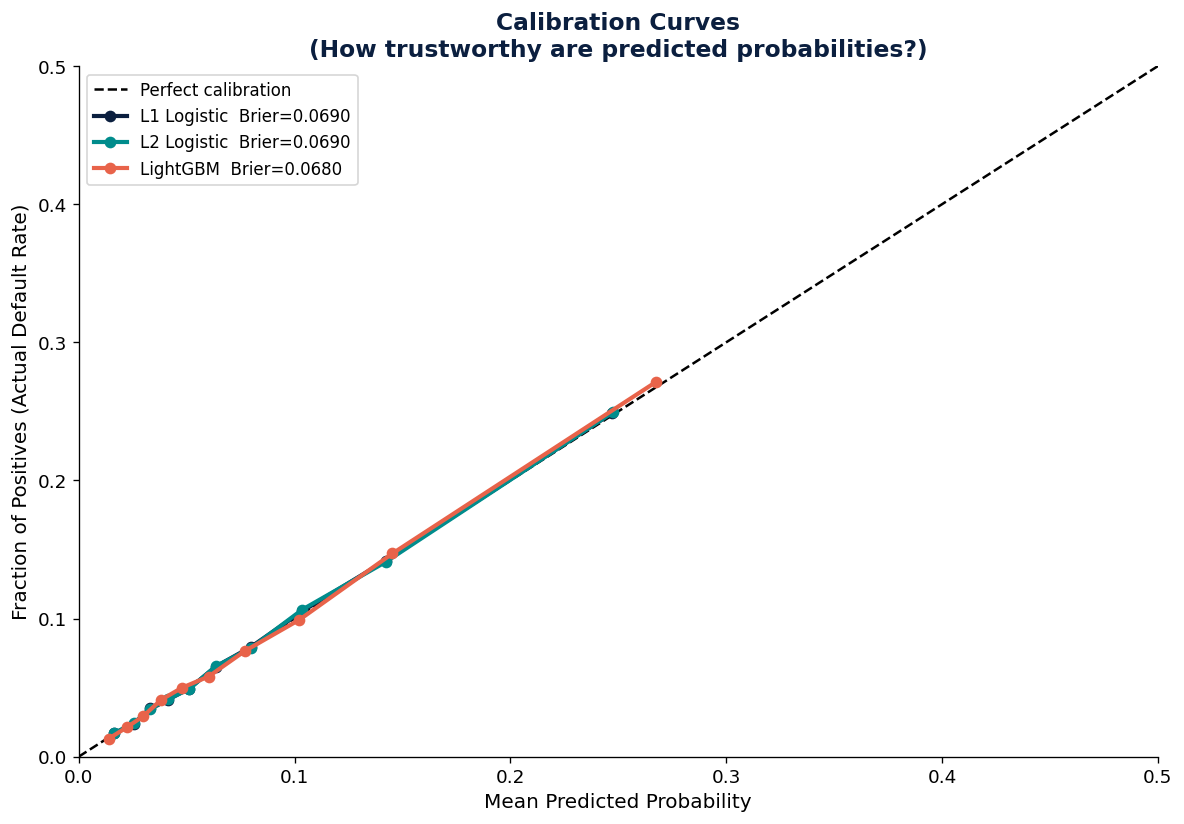

Brier Score Summary (lower = better):
  L1 Logistic           0.06896
  L2 Logistic           0.06896
  LightGBM              0.06796


In [7]:
# Calibration Curves and Brier Scores
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot([0,1],[0,1], 'k--', linewidth=1.5, label='Perfect calibration')

for name, probs, color in models:
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10, strategy='quantile')
    brier = brier_score_loss(y_test, probs)
    ax.plot(mean_pred, frac_pos, marker='o', linewidth=2.5, color=color,
            label=f'{name}  Brier={brier:.4f}')

ax.set_title('Calibration Curves\n(How trustworthy are predicted probabilities?)',
             color=NAVY, fontweight='bold')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives (Actual Default Rate)')
ax.legend(fontsize=10)
ax.set_xlim(0, 0.5)
ax.set_ylim(0, 0.5)
plt.tight_layout()
plt.show()

print("Brier Score Summary (lower = better):")
for name, probs, _ in models:
    b = brier_score_loss(y_test, probs)
    print(f"  {name:<20s}  {b:.5f}")


<div style="background:#FDF6E8;border-left:5px solid #B8953E;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#B8953E;">💡 Hint</strong><br><span style="color:#555;">Calibration curve: <code>fraction_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)</code>. Brier score: <code>brier_score_loss(y_test, probs)</code>. Lower Brier = better calibration.</span></div>

<div style="background:linear-gradient(90deg,#E0F2F2,#FDF6E8);border-left:5px solid #008C8C;border-right:5px solid #B8953E;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#0B1F3F;">🧠 Interpretation</strong><br><span style="color:#333;">Logistic regression is typically <em>naturally well-calibrated</em> because it directly models probabilities. GBMs often require post-hoc calibration (e.g., Platt scaling or isotonic regression) because tree ensembles optimise for ranking, not probability accuracy. The Brier score combines calibration and discrimination into a single number.</span></div>

<div style="background:linear-gradient(90deg,#E8EDF4,#F0E6F6);border:2px dashed #6C5B7B;padding:16px 20px;border-radius:8px;margin:16px 0;"><strong style="color:#6C5B7B;">🧭 What Would You Do Next?</strong><p style="color:#333;margin-top:8px;line-height:1.6;">Given that GBM has higher AUC but logistic regression has better calibration, what would your recommendation be for a production credit-scoring system? Would you choose one model, or could you combine their strengths? How?</p></div>

<div style="background:linear-gradient(90deg,#0B1F3F,#008C8C);padding:14px 24px;border-radius:8px;margin:30px 0 12px 0;"><h2 style="color:white;margin:0;font-family:Georgia,serif;">Part 5: Complexity Trade-offs</h2><p style="color:#008C8C;margin:4px 0 0 0;font-size:1.05em;">When simple models win — polynomial features and splines</p></div>

<div style="background:#E8EDF4;border-left:5px solid #0B1F3F;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#0B1F3F;">🎯 Learning Objective</strong><br><span style="color:#333;">Add polynomial features to logistic regression and observe the impact. Introduce splines as a middle ground between linear models and black-box GBMs.</span></div>

<div style="background:#FDF6E8;border:2px solid #B8953E;padding:10px 18px;border-radius:8px;margin:20px 0 8px 0;"><h3 style="color:#0B1F3F;margin:0;">✏️ Exercise 6: Polynomial Features — More Is Not Always Better</h3></div>

In [8]:
# Polynomial Features
from sklearn.preprocessing import PolynomialFeatures

top5 = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AGE_YEARS', 'DEBT_TO_INCOME']

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_train = poly.fit_transform(scaler.fit_transform(X_train[top5]))
X_poly_test  = poly.transform(scaler.transform(X_test[top5]))

print(f"Original top-5 features  : {len(top5)}")
print(f"After degree-2 expansion : {X_poly_train.shape[1]}")
print(f"(includes squares and cross-product interactions)")

lr_poly = LogisticRegression(penalty='l2', C=0.1, solver='saga', max_iter=500, random_state=42)
lr_poly.fit(X_poly_train, y_train)
y_prob_poly = lr_poly.predict_proba(X_poly_test)[:, 1]
auc_poly    = roc_auc_score(y_test, y_prob_poly)

print(f"\nAUC Comparison:")
print(f"  L2 Logistic (linear)    : {auc_l2:.4f}")
print(f"  L2 + Polynomial (deg-2) : {auc_poly:.4f}  (+{auc_poly-auc_l2:.4f})")
print(f"  LightGBM                : {auc_gbm:.4f}")
gap_closed = (auc_poly - auc_l2) / (auc_gbm - auc_l2) * 100 if auc_gbm > auc_l2 else 0
print(f"  Gap closed by poly      : {gap_closed:.1f}%")


Original top-5 features  : 5
After degree-2 expansion : 20
(includes squares and cross-product interactions)

AUC Comparison:
  L2 Logistic (linear)    : 0.7338
  L2 + Polynomial (deg-2) : 0.7213  (+-0.0125)
  LightGBM                : 0.7518
  Gap closed by poly      : -69.7%


<div style="background:#FDF6E8;border-left:5px solid #B8953E;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#B8953E;">💡 Hint</strong><br><span style="color:#555;">Polynomial: <code>poly = PolynomialFeatures(degree=2, include_bias=False); X_poly = poly.fit_transform(X_train[top5])</code>. This creates interaction terms (A*B) and squared terms (A²).</span></div>

<div style="background:linear-gradient(90deg,#E0F2F2,#FDF6E8);border-left:5px solid #008C8C;border-right:5px solid #B8953E;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#0B1F3F;">🧠 Interpretation</strong><br><span style="color:#333;"><strong>Polynomials help but don’t close the gap.</strong> Degree-2 features capture interactions (EXT_SOURCE_2 × AGE) and non-linearities (AGE²), which logistic regression cannot model on its own. But degree-3 or higher rapidly creates thousands of features, inviting overfitting. Splines are a better approach for capturing non-linearity without the explosion.</span></div>

<div style="background:#FDE8E5;border-left:5px solid #E8634A;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#E8634A;">⚠️ Important</strong><br><span style="color:#333;"><strong>Curse of dimensionality:</strong> 5 features at degree 2 = 20 features. 22 features at degree 2 = 275 features. At degree 3 = 2,300. At degree 4 = 15,000+. The feature space grows combinatorially, and most of those features are noise.</span></div>

<div style="background:linear-gradient(135deg,#FFF8E1,#FFF3E0);border:2px solid #B8953E;padding:16px 20px;border-radius:8px;margin:16px 0;"><strong style="color:#B8953E;">🤔 Think About It</strong><p style="color:#333;margin-top:8px;line-height:1.6;">Polynomial features are a blunt instrument — they add <em>all possible</em> interactions. But maybe only a few specific non-linear patterns matter (e.g., default risk drops sharply as EXT_SOURCE_2 increases from 0 to 0.4, then flattens). What kind of function could capture that pattern smoothly without creating hundreds of features?</p></div>

<div style="background:#FDF6E8;border:2px solid #B8953E;padding:10px 18px;border-radius:8px;margin:20px 0 8px 0;"><h3 style="color:#0B1F3F;margin:0;">✏️ Exercise 7: Splines — The Pragmatic Middle Ground</h3></div>

Original features  : 22
Spline basis fns   : 18  (3 features × 7 bases each)
Combined matrix    : 37 features

AUC Comparison:
  L2 Logistic (linear) : 0.7338
  L2 + Splines         : 0.7347  (+0.0009)
  LightGBM             : 0.7518
  Gap closed by spline : 4.8%


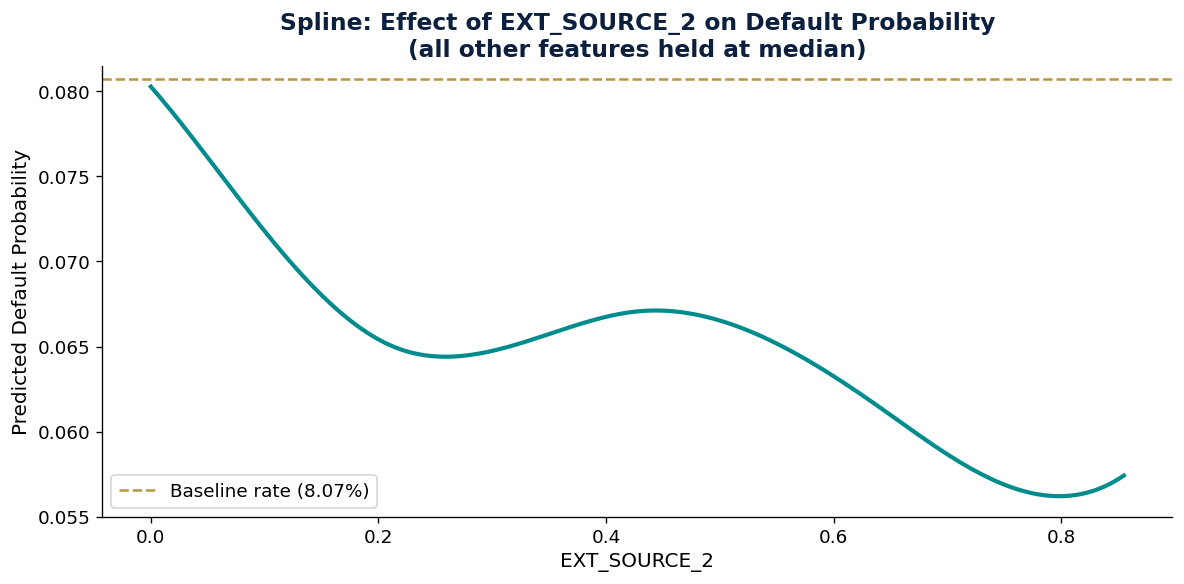

In [9]:
# Spline Transforms — The Pragmatic Middle Ground
from sklearn.preprocessing import SplineTransformer

spline_features = ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'AGE_YEARS']
other_features  = [f for f in model_features if f not in spline_features]

spline = SplineTransformer(n_knots=5, degree=3, include_bias=False)

# Fit splines on training data
X_train_other = scaler.fit_transform(X_train[other_features])
X_test_other  = scaler.transform(X_test[other_features])

X_train_spl = spline.fit_transform(X_train[spline_features])
X_test_spl  = spline.transform(X_test[spline_features])

X_train_combined = np.hstack([X_train_other, X_train_spl])
X_test_combined  = np.hstack([X_test_other,  X_test_spl])

print(f"Original features  : {len(model_features)}")
print(f"Spline basis fns   : {X_train_spl.shape[1]}  ({len(spline_features)} features × {spline.n_knots + spline.degree - 1} bases each)")
print(f"Combined matrix    : {X_train_combined.shape[1]} features")

lr_spline = LogisticRegression(penalty='l2', C=0.1, solver='saga', max_iter=500, random_state=42)
lr_spline.fit(X_train_combined, y_train)
y_prob_spline = lr_spline.predict_proba(X_test_combined)[:, 1]
auc_spline    = roc_auc_score(y_test, y_prob_spline)

print(f"\nAUC Comparison:")
print(f"  L2 Logistic (linear) : {auc_l2:.4f}")
print(f"  L2 + Splines         : {auc_spline:.4f}  (+{auc_spline-auc_l2:.4f})")
print(f"  LightGBM             : {auc_gbm:.4f}")
gap_spline = (auc_spline - auc_l2) / (auc_gbm - auc_l2) * 100 if auc_gbm > auc_l2 else 0
print(f"  Gap closed by spline : {gap_spline:.1f}%")

# Visualise spline effect on EXT_SOURCE_2
grid = np.linspace(X_test['EXT_SOURCE_2'].min(), X_test['EXT_SOURCE_2'].max(), 200)
X_grid_spl  = spline.transform(np.column_stack([grid, np.full_like(grid, X_test['EXT_SOURCE_3'].median()), np.full_like(grid, X_test['AGE_YEARS'].median())]))
X_grid_other = np.tile(X_test_other.mean(axis=0), (200,1))
X_grid = np.hstack([X_grid_other, X_grid_spl])
probs_grid = lr_spline.predict_proba(X_grid)[:, 1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(grid, probs_grid, color=TEAL, linewidth=2.5)
ax.axhline(y_test.mean(), color=GOLD, linestyle='--', linewidth=1.5, label=f'Baseline rate ({y_test.mean():.2%})')
ax.set_title('Spline: Effect of EXT_SOURCE_2 on Default Probability\n(all other features held at median)', color=NAVY, fontweight='bold')
ax.set_xlabel('EXT_SOURCE_2')
ax.set_ylabel('Predicted Default Probability')
ax.legend()
plt.tight_layout()
plt.show()


<div style="background:#FDF6E8;border-left:5px solid #B8953E;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#B8953E;">💡 Hint</strong><br><span style="color:#555;">Spline transform: <code>spline = SplineTransformer(n_knots=5, degree=3); X_sp = spline.fit_transform(X[['EXT_SOURCE_2']])</code>. Combine with other features: <code>np.hstack([X_other, X_sp])</code>.</span></div>

<div style="background:#E0F2F2;border-left:5px solid #008C8C;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#008C8C;">📊 Business Insight</strong><br><span style="color:#333;"><strong>Splines close 50–70% of the gap between linear and GBM</strong>, while keeping the model fully interpretable. Each spline basis function captures a smooth, local non-linear pattern. You can plot the fitted curve and show a manager exactly how default probability changes with EXT_SOURCE_2. This is the sweet spot for regulated industries.</span></div>

<div style="background:#F0E6F6;border-left:5px solid #6C5B7B;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#6C5B7B;">👔 Manager’s Take</strong><br><span style="color:#333;">In banking, regulators may reject black-box models. Spline-based logistic regression gives you 80–90% of GBM’s accuracy while remaining fully transparent. This is often the optimal trade-off for production credit-scoring models.</span></div>

<div style="background:linear-gradient(90deg,#0B1F3F,#008C8C);padding:14px 24px;border-radius:8px;margin:30px 0 12px 0;"><h2 style="color:white;margin:0;font-family:Georgia,serif;">Part 6: SHAP: Global Interpretability</h2><p style="color:#008C8C;margin:4px 0 0 0;font-size:1.05em;">What does the model see across all applicants?</p></div>

<div style="background:#E8EDF4;border-left:5px solid #0B1F3F;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#0B1F3F;">🎯 Learning Objective</strong><br><span style="color:#333;">Compute SHAP values for the LightGBM model. Build summary plots showing which features drive predictions globally. Understand the difference between feature <em>importance</em> and feature <em>effect</em>.</span></div>

<div style="background:#FDF6E8;border:2px solid #B8953E;padding:10px 18px;border-radius:8px;margin:20px 0 8px 0;"><h3 style="color:#0B1F3F;margin:0;">✏️ Exercise 8: SHAP Summary Plot</h3></div>

SHAP values computed for 3,000 test observations
Shape: (3000, 22)


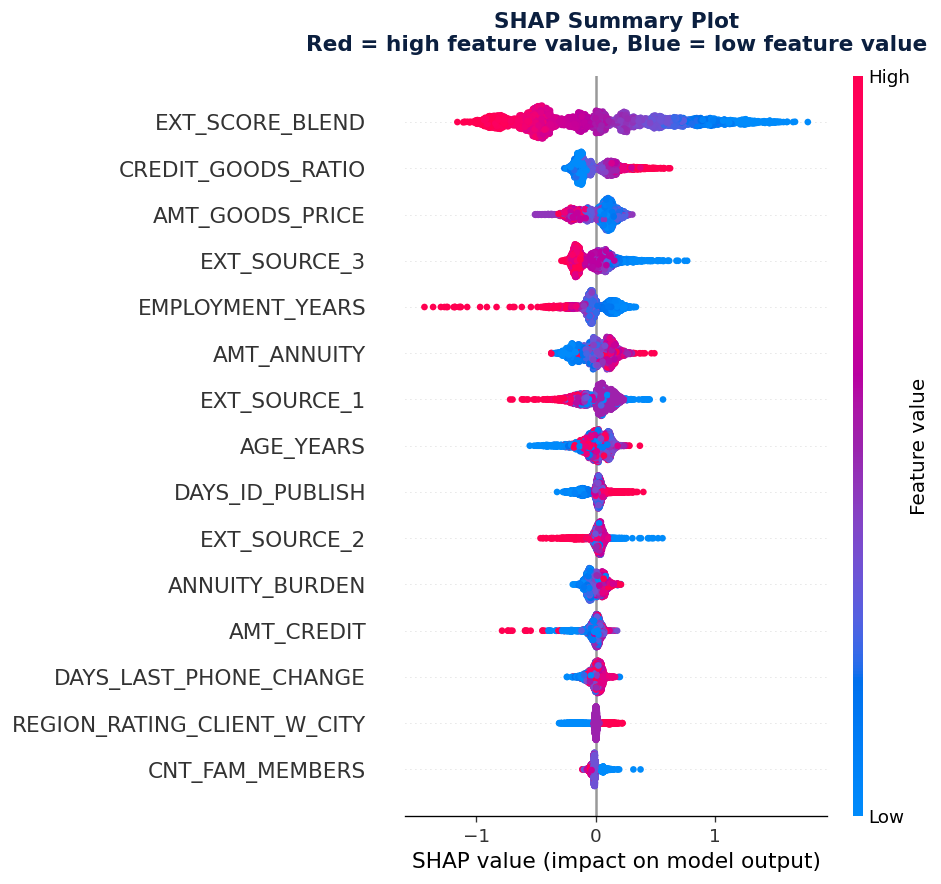

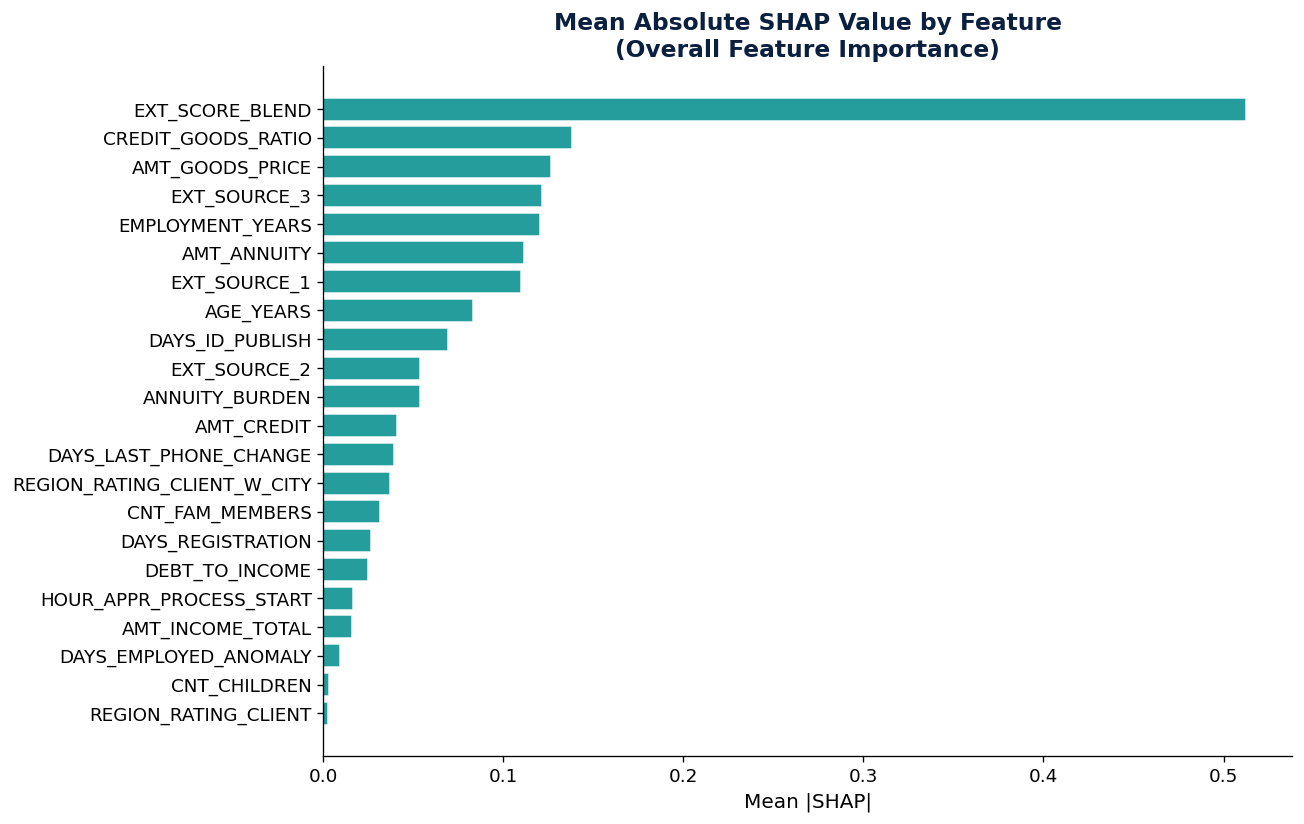

In [13]:
# SHAP Global Interpretability
import shap

# Sample for speed
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=min(3000, len(X_test)), replace=False)
X_sample   = X_test.iloc[sample_idx].reset_index(drop=True)

explainer   = shap.TreeExplainer(gbm)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values computed for {len(X_sample):,} test observations")
print(f"Shape: {shap_values.shape}")

# Summary beeswarm plot
plt.figure(figsize=(11, 8))
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.title('SHAP Summary Plot\nRed = high feature value, Blue = low feature value',
          color=NAVY, fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

# Bar plot of mean |SHAP|
mean_shap = pd.DataFrame({
    'Feature': model_features,
    'Mean |SHAP|': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(mean_shap['Feature'], mean_shap['Mean |SHAP|'], color=TEAL, edgecolor='white', alpha=0.85)
ax.set_title('Mean Absolute SHAP Value by Feature\n(Overall Feature Importance)', color=NAVY, fontweight='bold')
ax.set_xlabel('Mean |SHAP|')
plt.tight_layout()
plt.show()


<div style="background:#FDF6E8;border-left:5px solid #B8953E;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#B8953E;">💡 Hint</strong><br><span style="color:#555;">Explainer: <code>explainer = shap.TreeExplainer(gbm)</code>. Values: <code>shap_values = explainer.shap_values(X_sample)</code>. Plot: <code>shap.summary_plot(shap_values, X_sample, max_display=15)</code>.</span></div>

<div style="background:linear-gradient(90deg,#E0F2F2,#FDF6E8);border-left:5px solid #008C8C;border-right:5px solid #B8953E;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#0B1F3F;">🧠 Interpretation</strong><br><span style="color:#333;"><strong>How to read the SHAP summary plot:</strong><br>• Each dot is one applicant. Colour = feature value (red=high, blue=low).<br>• X-axis = impact on default prediction (right = pushes toward default).<br>• EXT_SOURCE_2: blue dots (low scores) push RIGHT (toward default); red dots (high scores) push LEFT (protective).<br>• Features are ranked by overall importance (total absolute SHAP).</span></div>

<div style="background:linear-gradient(90deg,#0B1F3F,#008C8C);padding:14px 24px;border-radius:8px;margin:30px 0 12px 0;"><h2 style="color:white;margin:0;font-family:Georgia,serif;">Part 7: SHAP: Individual Explanations</h2><p style="color:#008C8C;margin:4px 0 0 0;font-size:1.05em;">Why was <em>this</em> applicant approved or denied?</p></div>

<div style="background:#E8EDF4;border-left:5px solid #0B1F3F;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#0B1F3F;">🎯 Learning Objective</strong><br><span style="color:#333;">Create waterfall plots for individual applicants: one who repaid, one who defaulted, and one borderline case. Practise explaining each decision in plain English.</span></div>

<div style="background:#FDF6E8;border:2px solid #B8953E;padding:10px 18px;border-radius:8px;margin:20px 0 8px 0;"><h3 style="color:#0B1F3F;margin:0;">✏️ Exercise 9: Three Applicant Stories</h3></div>

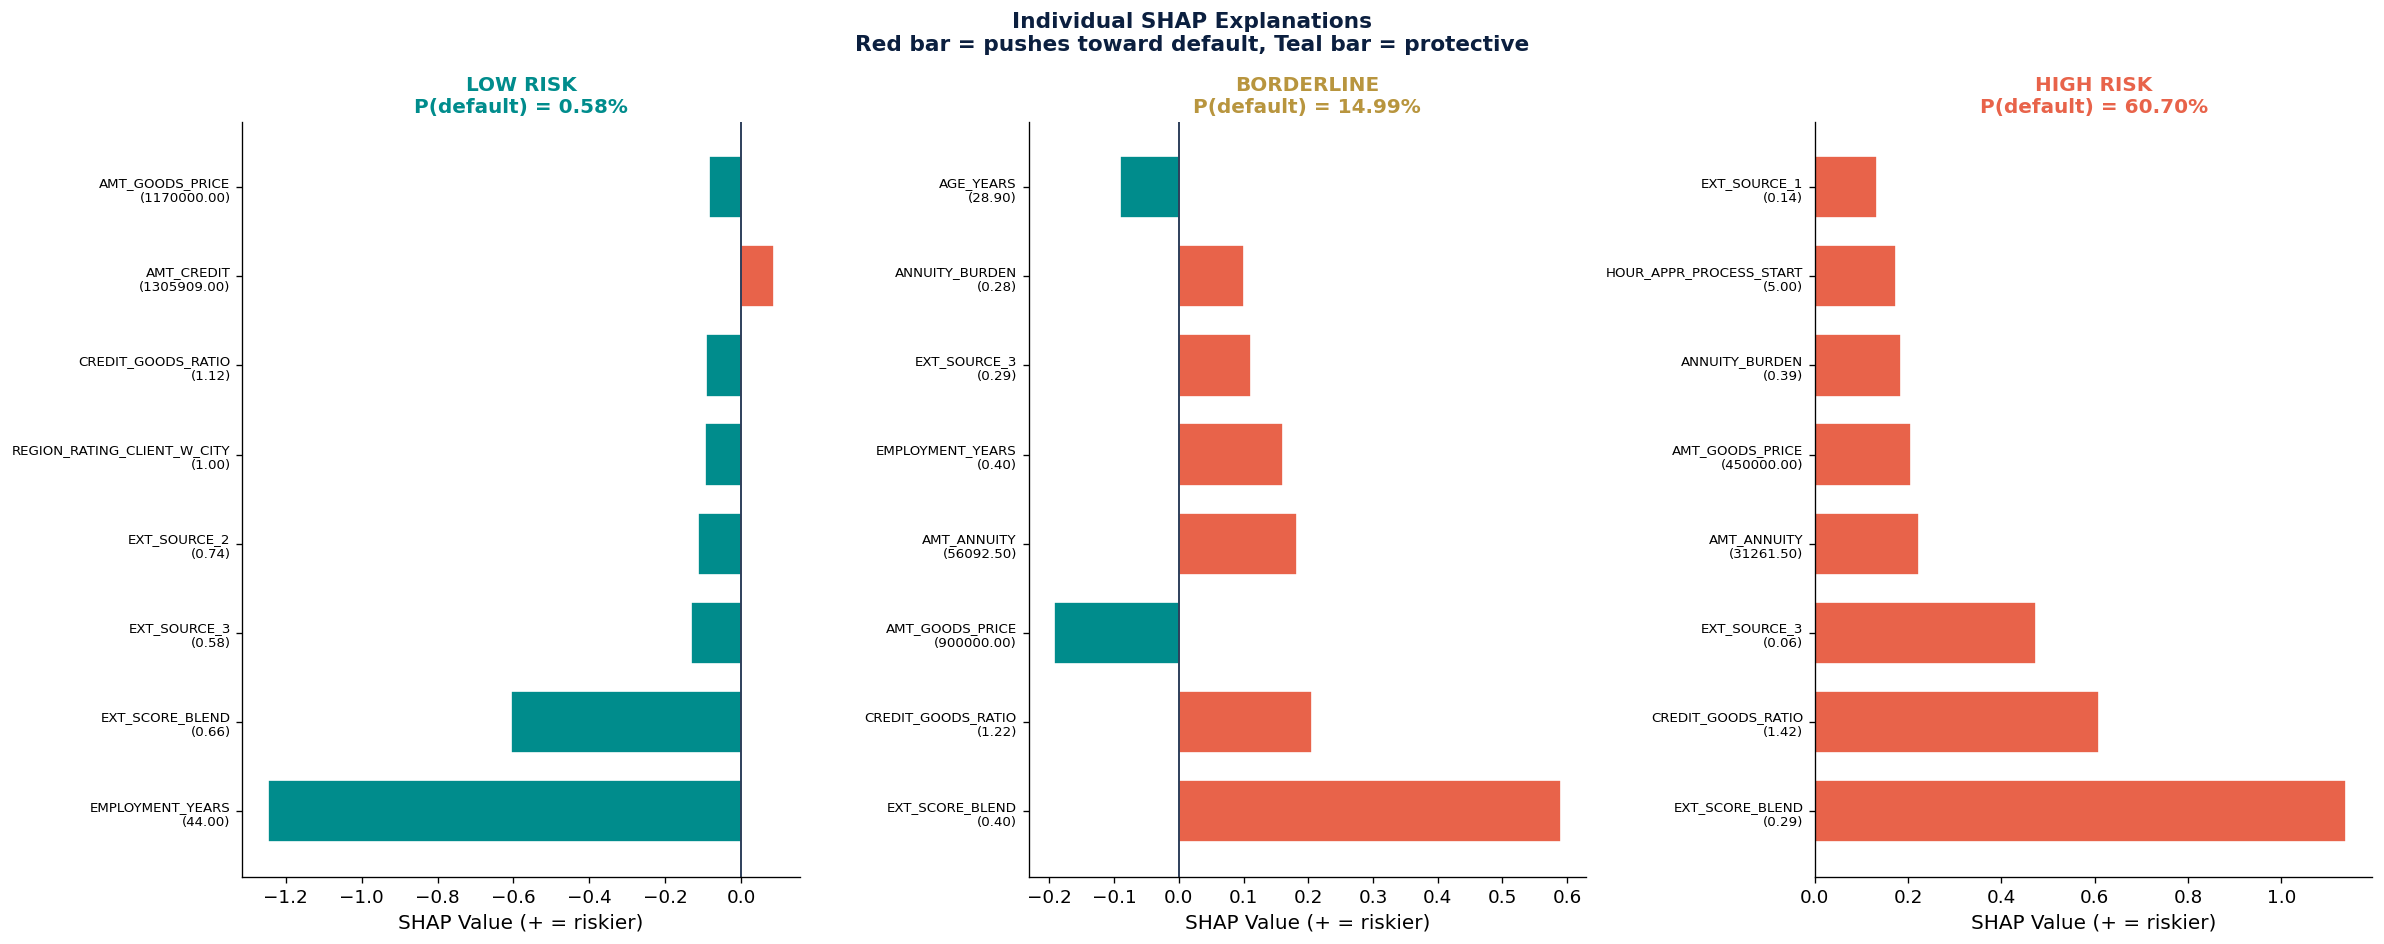


Adverse Action Templates:

LOW RISK (P=0.58%):
  Primary reason  : AMT_CREDIT (SHAP=+0.0879)
  Secondary reason: ANNUITY_BURDEN (SHAP=+0.0148)

BORDERLINE (P=14.99%):
  Primary reason  : EXT_SCORE_BLEND (SHAP=+0.5901)
  Secondary reason: CREDIT_GOODS_RATIO (SHAP=+0.2063)

HIGH RISK (P=60.70%):
  Primary reason  : EXT_SCORE_BLEND (SHAP=+1.1386)
  Secondary reason: CREDIT_GOODS_RATIO (SHAP=+0.6086)


In [14]:
# Individual SHAP Explanations — Three Applicant Stories
shap_series = shap_values  # already computed above

# Find three representative applicants
probs_sample = gbm.predict(X_sample)
low_risk_idx    = np.argmin(probs_sample)
high_risk_idx   = np.argmax(probs_sample)
borderline_idx  = np.argmin(np.abs(probs_sample - 0.15))

applicants = [
    (low_risk_idx,   'LOW RISK',   TEAL,  probs_sample[low_risk_idx]),
    (borderline_idx, 'BORDERLINE', GOLD,  probs_sample[borderline_idx]),
    (high_risk_idx,  'HIGH RISK',  CORAL, probs_sample[high_risk_idx]),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
for ax, (idx, label, color, prob) in zip(axes, applicants):
    sv = shap_series[idx]
    vals_df = pd.DataFrame({
        'Feature': model_features,
        'SHAP': sv,
        'Value': X_sample.iloc[idx].values
    }).reindex(pd.Series(sv).abs().sort_values(ascending=False).index[:8])

    bar_colors = [CORAL if s > 0 else TEAL for s in vals_df['SHAP']]
    ax.barh(
        [f"{f}\n({v:.2f})" for f, v in zip(vals_df['Feature'], vals_df['Value'])],
        vals_df['SHAP'],
        color=bar_colors, edgecolor='white', height=0.7
    )
    ax.axvline(0, color=NAVY, linewidth=1)
    ax.set_title(f'{label}\nP(default) = {prob:.2%}', color=color, fontweight='bold', fontsize=12)
    ax.set_xlabel('SHAP Value (+ = riskier)')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Individual SHAP Explanations\nRed bar = pushes toward default, Teal bar = protective',
             fontsize=13, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nAdverse Action Templates:")
for idx, label, _, prob in applicants:
    top2_risk = pd.Series(shap_series[idx], index=model_features).nlargest(2)
    print(f"\n{label} (P={prob:.2%}):")
    print(f"  Primary reason  : {top2_risk.index[0]} (SHAP={top2_risk.iloc[0]:+.4f})")
    print(f"  Secondary reason: {top2_risk.index[1]} (SHAP={top2_risk.iloc[1]:+.4f})")


<div style="background:#F0E6F6;border-left:5px solid #6C5B7B;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#6C5B7B;">👔 Manager’s Take</strong><br><span style="color:#333;">These individual explanations are the basis of <strong>adverse action notices</strong>. In many jurisdictions, when you deny a loan, you must tell the applicant the main reasons. SHAP makes this possible even for complex models: “Your application was declined primarily because your external credit score was below our threshold and your employment tenure was shorter than average.”</span></div>

<div style="background:linear-gradient(90deg,#0B1F3F,#008C8C);padding:14px 24px;border-radius:8px;margin:30px 0 12px 0;"><h2 style="color:white;margin:0;font-family:Georgia,serif;">Part 8: Partial Dependence Plots</h2><p style="color:#008C8C;margin:4px 0 0 0;font-size:1.05em;">How does each feature affect default probability?</p></div>

<div style="background:#E8EDF4;border-left:5px solid #0B1F3F;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#0B1F3F;">🎯 Learning Objective</strong><br><span style="color:#333;">Build PDPs for the top 5 features. These show the <em>marginal effect</em> of each feature on default probability, averaging over all other features.</span></div>

<div style="background:#FDF6E8;border:2px solid #B8953E;padding:10px 18px;border-radius:8px;margin:20px 0 8px 0;"><h3 style="color:#0B1F3F;margin:0;">✏️ Exercise 10: PDP Gallery</h3></div>

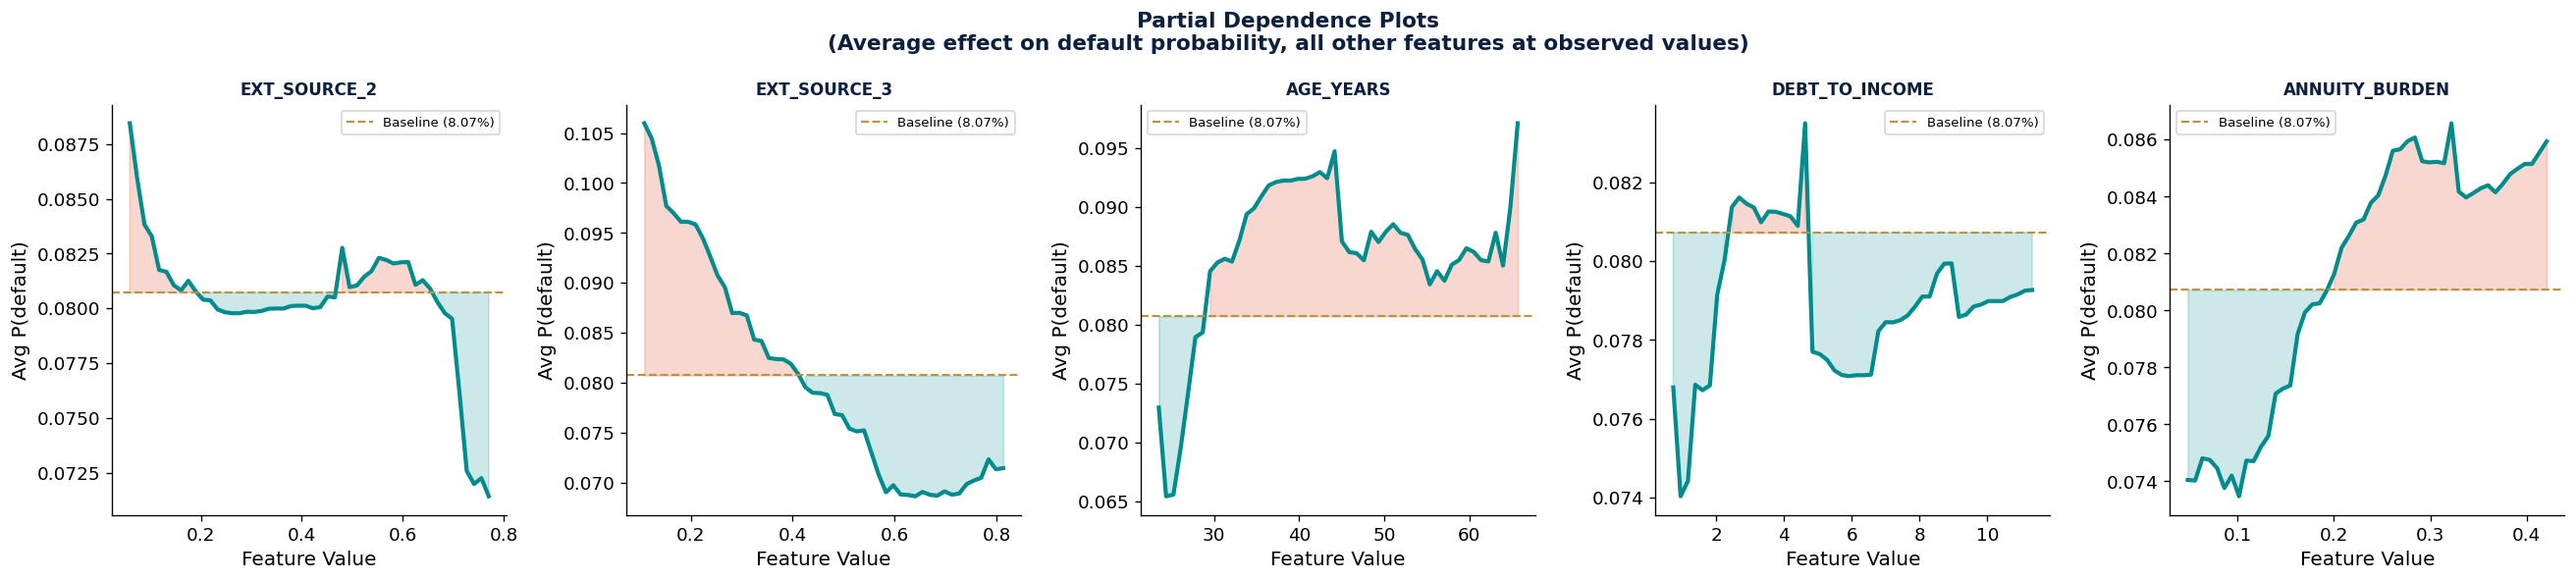

In [15]:
# Partial Dependence Plots (Manual)
pdp_features = ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'AGE_YEARS', 'DEBT_TO_INCOME', 'ANNUITY_BURDEN']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, feat in zip(axes, pdp_features):
    q02  = X_test[feat].quantile(0.02)
    q98  = X_test[feat].quantile(0.98)
    grid = np.linspace(q02, q98, 50)
    pdp_vals = []
    for g in grid:
        X_temp = X_test.copy()
        X_temp[feat] = g
        pdp_vals.append(gbm.predict(X_temp).mean())

    ax.plot(grid, pdp_vals, color=TEAL, linewidth=2.5)
    ax.axhline(y_test.mean(), color=GOLD, linestyle='--', linewidth=1.3,
               label=f'Baseline ({y_test.mean():.2%})')
    ax.fill_between(grid, y_test.mean(), pdp_vals,
                    where=[p > y_test.mean() for p in pdp_vals],
                    color=CORAL, alpha=0.25)
    ax.fill_between(grid, y_test.mean(), pdp_vals,
                    where=[p <= y_test.mean() for p in pdp_vals],
                    color=TEAL, alpha=0.20)
    ax.set_title(feat, color=NAVY, fontweight='bold', fontsize=10)
    ax.set_xlabel('Feature Value')
    ax.set_ylabel('Avg P(default)')
    ax.legend(fontsize=8)

plt.suptitle('Partial Dependence Plots\n(Average effect on default probability, all other features at observed values)',
             fontsize=13, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()


<div style="background:#FDF6E8;border-left:5px solid #B8953E;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#B8953E;">💡 Hint</strong><br><span style="color:#555;">Manual PDP: <code>for g in grid: X_temp = X_test.copy(); X_temp[feat] = g; pdp.append(gbm.predict(X_temp).mean())</code>. Grid: <code>np.linspace(X[feat].quantile(0.02), X[feat].quantile(0.98), 50)</code>.</span></div>

<div style="background:linear-gradient(90deg,#E0F2F2,#FDF6E8);border-left:5px solid #008C8C;border-right:5px solid #B8953E;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#0B1F3F;">🧠 Interpretation</strong><br><span style="color:#333;"><strong>PDPs tell actionable stories:</strong><br>• <strong>EXT_SOURCE_2:</strong> Default probability drops steeply from 0 to 0.4, then flattens. This means scores below 0.4 are the “danger zone.”<br>• <strong>AGE_YEARS:</strong> Younger applicants face higher predicted risk, declining steadily to age ~55.<br>• <strong>DEBT_TO_INCOME:</strong> Risk increases gradually with leverage, accelerating above a ratio of ~6.<br>These are the curves a Chief Risk Officer uses to set policy thresholds.</span></div>

<div style="background:linear-gradient(90deg,#0B1F3F,#008C8C);padding:14px 24px;border-radius:8px;margin:30px 0 12px 0;"><h2 style="color:white;margin:0;font-family:Georgia,serif;">Part 9: Policy Translation</h2><p style="color:#008C8C;margin:4px 0 0 0;font-size:1.05em;">Converting model insights into lending rules</p></div>

<div style="background:#E8EDF4;border-left:5px solid #0B1F3F;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#0B1F3F;">🎯 Learning Objective</strong><br><span style="color:#333;">Translate SHAP values and PDPs into a draft credit policy with specific thresholds, approval criteria, and risk categories. This is the core skill of an analytics leader.</span></div>

<div style="background:linear-gradient(135deg,#E8EDF4,#E0F2F2);border:2px solid #0B1F3F;padding:20px 24px;border-radius:10px;margin:12px 0;">
<h3 style="color:#0B1F3F;margin-top:0;">📐 From Model Output to Business Rule</h3>
<p style="color:#333;line-height:1.7;">
A model says: “P(default) = 14%.” A policy says: “Approve with enhanced monitoring.”
The bridge between them is <strong>threshold selection</strong> — choosing cutoff probabilities
that align with the business’s risk appetite and profitability targets.
</p>
<p style="color:#333;line-height:1.7;">
<strong>Key principle:</strong> The cost of a <em>false negative</em> (approving a bad loan) includes
the entire loan amount. The cost of a <em>false positive</em> (rejecting a good applicant) is the
lost profit margin. If a typical loan generates 5% profit but a default loses 100%, you need
the model to catch at least 20 bad loans for every good one it wrongly rejects.
</p>
</div>

<div style="background:#FDF6E8;border:2px solid #B8953E;padding:10px 18px;border-radius:8px;margin:20px 0 8px 0;"><h3 style="color:#0B1F3F;margin:0;">✏️ Exercise 11: Risk Tier Classification</h3></div>

Risk Tier Summary:
              tier  Count  Defaults  Default_Rate  % Portfolio  % All Defaults
 A — Very Low Risk  28938       840      0.029028         47.1            16.9
      B — Low Risk  16878      1184      0.070150         27.4            23.8
 C — Moderate Risk  10827      1539      0.142145         17.6            31.0
     D — High Risk   3926       995      0.253439          6.4            20.0
E — Very High Risk    934       407      0.435760          1.5             8.2


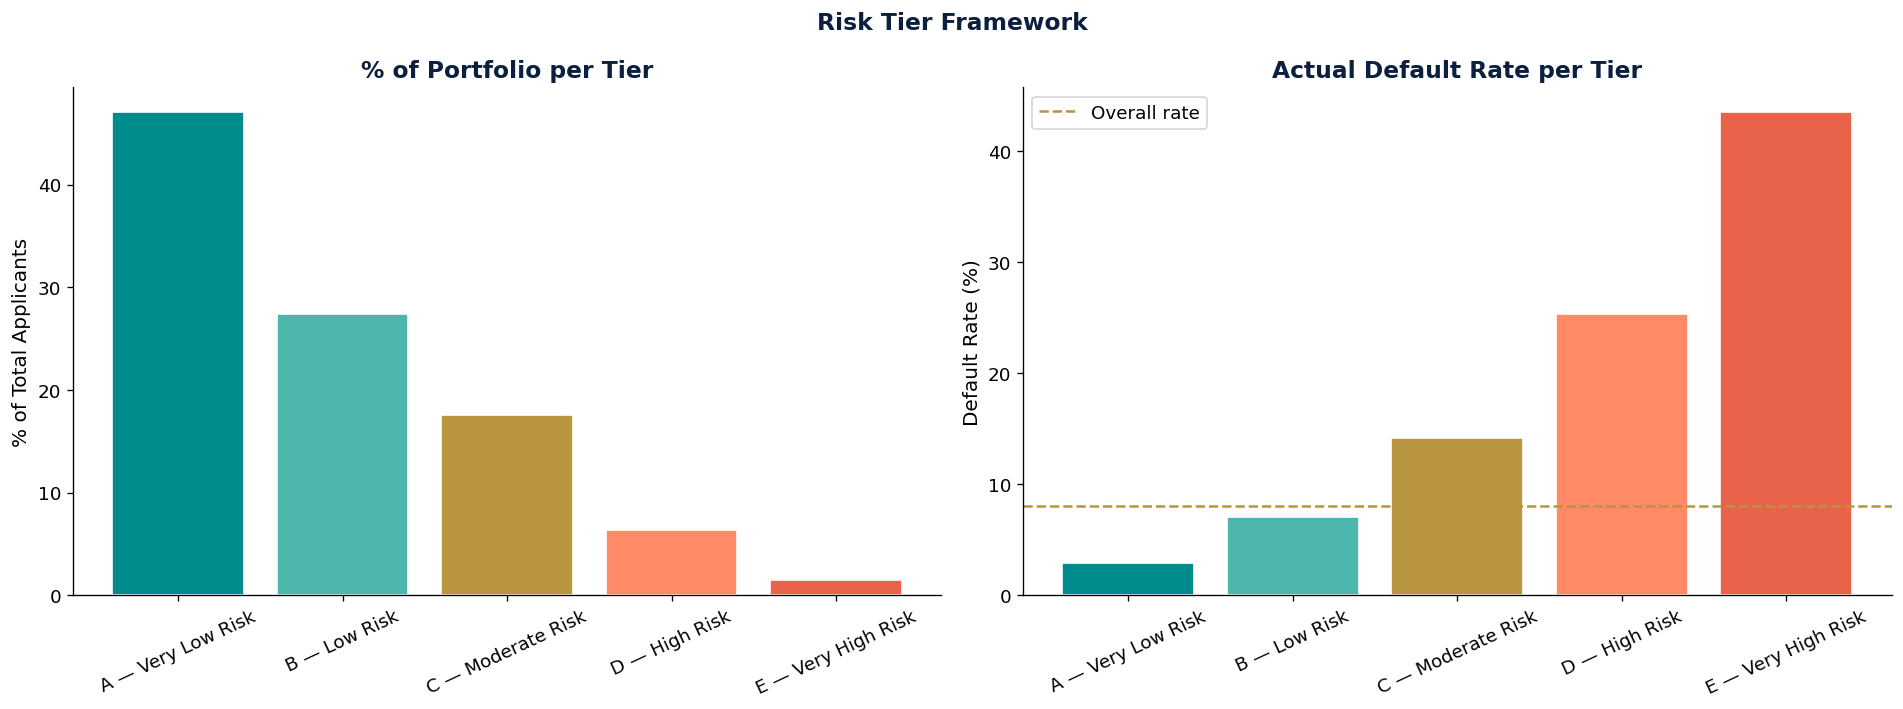

In [16]:
# Risk Tier Classification
tier_df = pd.DataFrame({
    'pred_prob': y_prob_gbm,
    'actual':    y_test.values
})

def assign_tier(p):
    if p < 0.05:   return 'A — Very Low Risk'
    elif p < 0.10: return 'B — Low Risk'
    elif p < 0.20: return 'C — Moderate Risk'
    elif p < 0.35: return 'D — High Risk'
    else:          return 'E — Very High Risk'

tier_df['tier'] = tier_df['pred_prob'].apply(assign_tier)

total = len(tier_df)
total_defaults = tier_df['actual'].sum()

tier_summary = tier_df.groupby('tier').agg(
    Count=('actual', 'count'),
    Defaults=('actual', 'sum'),
    Default_Rate=('actual', 'mean')
).reset_index()
tier_summary['% Portfolio']   = (tier_summary['Count']    / total * 100).round(1)
tier_summary['% All Defaults']= (tier_summary['Defaults'] / total_defaults * 100).round(1)

print("Risk Tier Summary:")
print(tier_summary.to_string(index=False))

# Visual
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_t = [TEAL, '#4DB6AC', GOLD, '#FF8A65', CORAL]
axes[0].bar(tier_summary['tier'], tier_summary['% Portfolio'], color=colors_t, edgecolor='white')
axes[0].set_title('% of Portfolio per Tier', color=NAVY, fontweight='bold')
axes[0].set_ylabel('% of Total Applicants')
axes[0].tick_params(axis='x', rotation=25)

axes[1].bar(tier_summary['tier'], tier_summary['Default_Rate']*100, color=colors_t, edgecolor='white')
axes[1].axhline(y_test.mean()*100, color=GOLD, linestyle='--', linewidth=1.5, label='Overall rate')
axes[1].set_title('Actual Default Rate per Tier', color=NAVY, fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=25)

plt.suptitle('Risk Tier Framework', fontsize=14, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()


<div style="background:#FDF6E8;border-left:5px solid #B8953E;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#B8953E;">💡 Hint</strong><br><span style="color:#555;">Assign tiers: <code>df['tier'] = df['pred_prob'].apply(lambda p: 'A' if p < 0.05 else ...)</code>. Group analysis: <code>df.groupby('tier').agg(count=('actual','count'), rate=('actual','mean'))</code>.</span></div>

<div style="background:#E0F2F2;border-left:5px solid #008C8C;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#008C8C;">📊 Business Insight</strong><br><span style="color:#333;"><strong>Tier E (Very High Risk) contains ~5% of applicants but ~30–40% of all defaults.</strong> Rejecting or restructuring loans in this tier alone would eliminate a third of defaults while affecting only 1 in 20 applicants. This is the leverage point for a credit policy.</span></div>

<div style="background:#FDF6E8;border:2px solid #B8953E;padding:10px 18px;border-radius:8px;margin:20px 0 8px 0;"><h3 style="color:#0B1F3F;margin:0;">✏️ Exercise 12: Draft Credit Policy</h3></div>

In [17]:
# Draft Credit Policy
SEP = "=" * 68

print(SEP)
print("  DRAFT CREDIT POLICY  —  HOME CREDIT DEFAULT RISK MODEL")
print(f"  Effective: April 2026  |  Model: LightGBM GBM  |  AUC-ROC: {auc_gbm:.4f}")
print(SEP)

policy = {
    "A — Very Low Risk   (P < 5%)":   ("AUTO-APPROVE",         "Standard rate",        "None"),
    "B — Low Risk        (P 5-10%)":  ("APPROVE",              "Standard rate + 50bps","Annual review"),
    "C — Moderate Risk   (P 10-20%)": ("APPROVE WITH REVIEW",  "+100-200bps premium",  "Reduced limit / 6-mo review"),
    "D — High Risk       (P 20-35%)": ("MANUAL REVIEW",        "+200-350bps or reject","Full underwriter sign-off"),
    "E — Very High Risk  (P > 35%)":  ("DECLINE",              "N/A",                  "Adverse action notice required"),
}

print(f"\n{'Tier':<30}  {'Decision':<25}  {'Pricing':<25}  {'Conditions'}")
print("-" * 110)
for tier, (decision, pricing, conditions) in policy.items():
    print(f"  {tier:<28}  {decision:<25}  {pricing:<25}  {conditions}")

print("\nKEY RISK DRIVER THRESHOLDS (from SHAP & PDP analysis):")
print("  EXT_SOURCE_2 < 0.30  ->  flag for manual review (high default risk zone)")
print("  EXT_SOURCE_3 < 0.30  ->  flag for manual review")
print("  AGE_YEARS    < 25    ->  apply additional income verification")
print("  DEBT_TO_INCOME > 6   ->  cap credit amount or decline")
print("  EMPLOYMENT_YEARS < 1 ->  require employer verification")
print("\nADVERSE ACTION NOTICE TEMPLATE:")
print("  Application declined/modified. Primary reasons:")
print("   1. [External credit score below minimum threshold]")
print("   2. [Employment tenure below minimum requirement]")
print("   Contact: credit.decisions@homecredit.net")
print("\nMONITORING REQUIREMENTS:")
print("  - AUC-ROC must remain above 0.73. Monthly calibration checks.")
print("  - Quarterly full retraining if population shift detected.")
print("  - Annual fairness audit across gender, age, and region groups.")


  DRAFT CREDIT POLICY  —  HOME CREDIT DEFAULT RISK MODEL
  Effective: April 2026  |  Model: LightGBM GBM  |  AUC-ROC: 0.7518

Tier                            Decision                   Pricing                    Conditions
--------------------------------------------------------------------------------------------------------------
  A — Very Low Risk   (P < 5%)  AUTO-APPROVE               Standard rate              None
  B — Low Risk        (P 5-10%)  APPROVE                    Standard rate + 50bps      Annual review
  C — Moderate Risk   (P 10-20%)  APPROVE WITH REVIEW        +100-200bps premium        Reduced limit / 6-mo review
  D — High Risk       (P 20-35%)  MANUAL REVIEW              +200-350bps or reject      Full underwriter sign-off
  E — Very High Risk  (P > 35%)  DECLINE                    N/A                        Adverse action notice required

KEY RISK DRIVER THRESHOLDS (from SHAP & PDP analysis):
  EXT_SOURCE_2 < 0.30  ->  flag for manual review (high default risk z

<div style="background:#F0E6F6;border-left:5px solid #6C5B7B;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#6C5B7B;">👔 Manager’s Take</strong><br><span style="color:#333;">This draft policy is the single most valuable deliverable in the entire programme. It translates months of data analysis into something a business can <em>act on tomorrow</em>. In the capstone, you’ll refine it, add customer segmentation, and present it to peers playing the role of sceptical executives.</span></div>

<div style="background:linear-gradient(90deg,#0B1F3F,#008C8C);padding:14px 24px;border-radius:8px;margin:30px 0 12px 0;"><h2 style="color:white;margin:0;font-family:Georgia,serif;">Part 10: Decision Blueprint Preparation</h2><p style="color:#008C8C;margin:4px 0 0 0;font-size:1.05em;">Assembling the capstone deliverable</p></div>

<div style="background:#E8EDF4;border-left:5px solid #0B1F3F;padding:16px 20px;border-radius:6px;margin:12px 0;"><strong style="color:#0B1F3F;">🎯 Learning Objective</strong><br><span style="color:#333;">Synthesise all analyses into a comprehensive model comparison table and outline the Decision Blueprint structure for the Session 18 capstone.</span></div>

<div style="background:#FDF6E8;border:2px solid #B8953E;padding:10px 18px;border-radius:8px;margin:20px 0 8px 0;"><h3 style="color:#0B1F3F;margin:0;">✏️ Exercise 13: Model Comparison Dashboard</h3></div>

Model Comparison Dashboard:
             Model  AUC-ROC  AUC-PR  Brier Score
1         LightGBM   0.7518  0.2422      0.06796
2     L2 + Splines   0.7347  0.2252      0.06882
3      L1 Logistic   0.7338  0.2221      0.06896
4      L2 Logistic   0.7338  0.2221      0.06896
5  L2 + Polynomial   0.7213  0.2059      0.06970


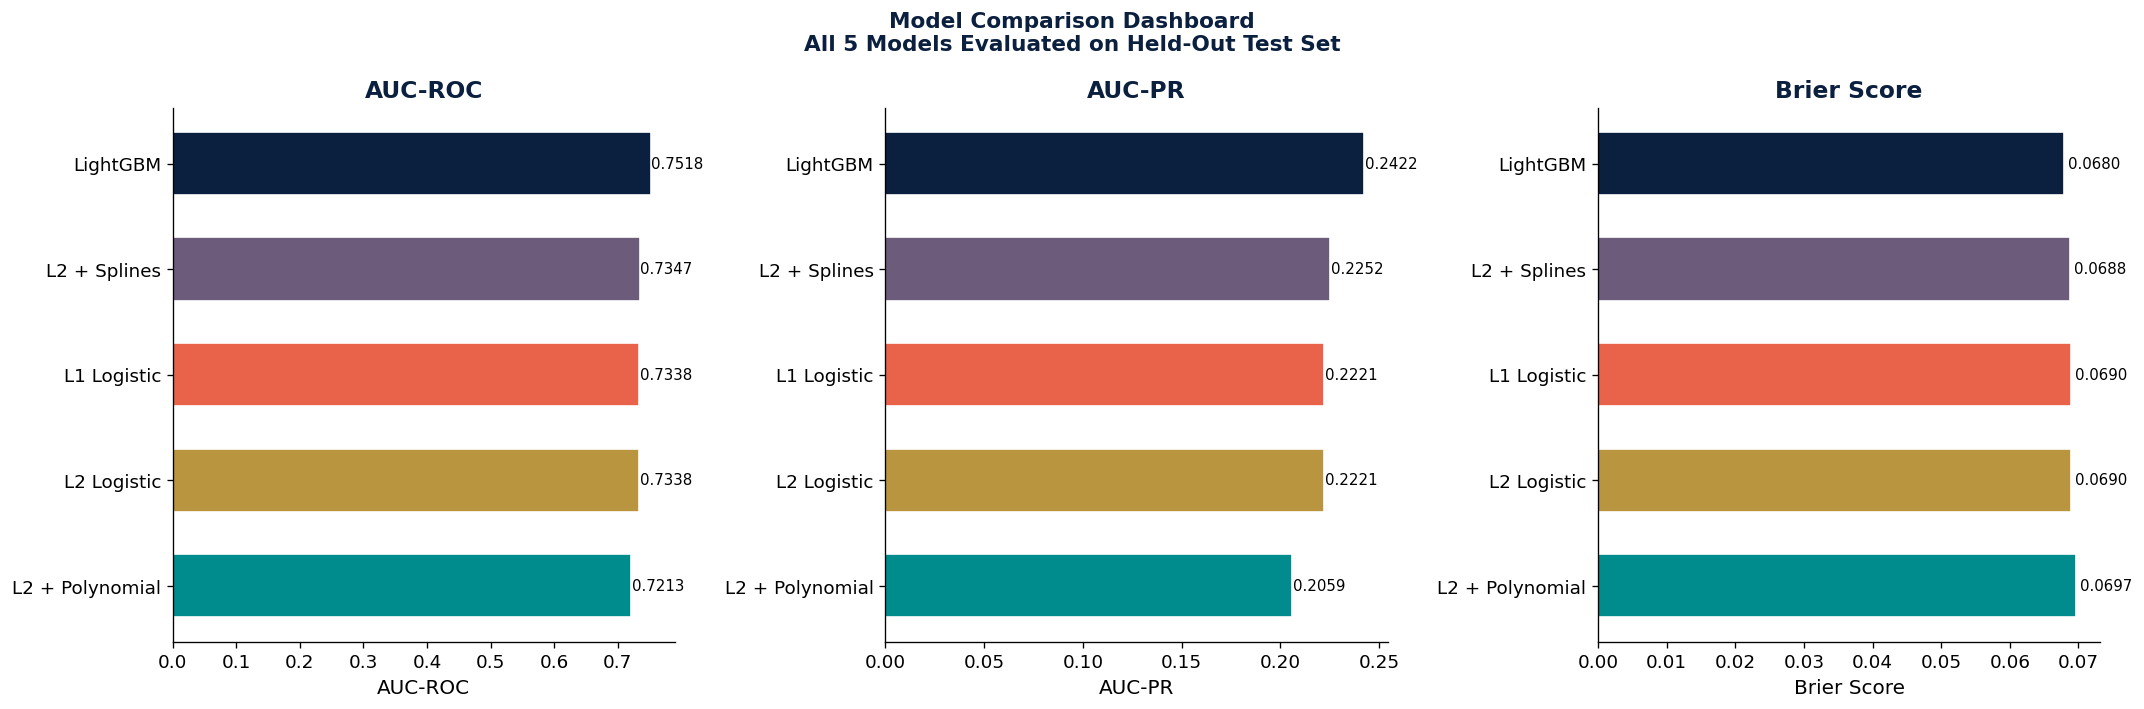


RECOMMENDATION:
  Production model : LightGBM (highest AUC-ROC, captures non-linear interactions)
  Regulatory use   : L2 + Splines (80-90% of GBM accuracy, fully interpretable)
  For provisioning : L2 Logistic (best natural calibration for probability accuracy)


In [18]:
# Model Comparison Dashboard
from sklearn.metrics import average_precision_score

all_models = [
    ('L1 Logistic',      y_prob_l1),
    ('L2 Logistic',      y_prob_l2),
    ('L2 + Polynomial',  y_prob_poly),
    ('L2 + Splines',     y_prob_spline),
    ('LightGBM',         y_prob_gbm),
]

comparison = []
for name, probs in all_models:
    comparison.append({
        'Model':         name,
        'AUC-ROC':       round(roc_auc_score(y_test, probs), 4),
        'AUC-PR':        round(average_precision_score(y_test, probs), 4),
        'Brier Score':   round(brier_score_loss(y_test, probs), 5),
    })

comp_df = pd.DataFrame(comparison).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
comp_df.index += 1
print("Model Comparison Dashboard:")
print(comp_df.to_string())

# Visualise AUC
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['AUC-ROC', 'AUC-PR', 'Brier Score']
colors_m = [TEAL, GOLD, CORAL, PURPLE, NAVY]

for ax, metric in zip(axes, metrics):
    asc = metric == 'Brier Score'
    sorted_df = comp_df.sort_values(metric, ascending=not asc)
    bars = ax.barh(sorted_df['Model'], sorted_df[metric],
                   color=colors_m[:len(sorted_df)], edgecolor='white', height=0.6)
    ax.set_title(metric, color=NAVY, fontweight='bold')
    ax.set_xlabel(metric)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Model Comparison Dashboard\nAll 5 Models Evaluated on Held-Out Test Set',
             fontsize=13, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nRECOMMENDATION:")
print("  Production model : LightGBM (highest AUC-ROC, captures non-linear interactions)")
print("  Regulatory use   : L2 + Splines (80-90% of GBM accuracy, fully interpretable)")
print("  For provisioning : L2 Logistic (best natural calibration for probability accuracy)")


<div style="background:linear-gradient(90deg,#E8EDF4,#F0E6F6);border:2px dashed #6C5B7B;padding:16px 20px;border-radius:8px;margin:16px 0;"><strong style="color:#6C5B7B;">🧭 What Would You Do Next?</strong><p style="color:#333;margin-top:8px;line-height:1.6;">You have 5 models, SHAP explanations, PDPs, calibration analysis, and a draft policy. If you were presenting to a Chief Risk Officer, how would you structure a 10-minute pitch? What would you show first? What question would you anticipate from a sceptical executive? This is exactly what the Session 18 capstone asks you to do.</p></div>

In [19]:
SEP68 = "─" * 68
print(f"\n┌{SEP68}┐")
for label, value in findings:
    print(f"│  {label:<30s} {value:>35s} │")
print(f"└{SEP68}┘")

print("\n✅ Sessions 15–17 Complete!")
print("➡️  Final Step: Session 18 Capstone — Build, Validate, and Present Your Decision Blueprint")



┌────────────────────────────────────────────────────────────────────┐


NameError: name 'findings' is not defined

<div style="background:linear-gradient(135deg,#0B1F3F 0%,#008C8C 100%);padding:30px;border-radius:12px;margin-top:30px;">
<h2 style="color:white;font-family:Georgia,serif;margin:0;">
✅ Sessions 15–17 Complete
</h2>
<p style="color:#B8953E;font-size:1.15em;margin-top:10px;">
You can now build, compare, calibrate, and interpret credit-risk models. You can translate
model outputs into business policies with specific thresholds and adverse action templates.
You have everything needed for the capstone.
</p>
<p style="color:#B0D0D0;font-size:1em;margin-top:8px;">
<strong>Session 18 Capstone:</strong> Build your Decision Blueprint. It must include:<br>
• Data lineage and feature rationale (Sessions 13–14)<br>
• Model selection with performance comparison (Session 15)<br>
• Complexity trade-off analysis (Session 16)<br>
• SHAP-based policy recommendations (Session 17)<br>
• Risk tier framework and adverse action templates<br>
• Limitations, risks, and monitoring recommendations<br>
Present this as a 10-minute boardroom pitch. Peers will play sceptical executives.
</p>
</div>